In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix

In [76]:
#Load Image Dataset
digits = load_digits()
X = digits.data        # Flattened images (64 features)
y = digits.target      # Labels (0–9)

print('Data shape:', X.shape)
print('Image shape:', digits.images[0].shape)

Data shape: (1797, 64)
Image shape: (8, 8)


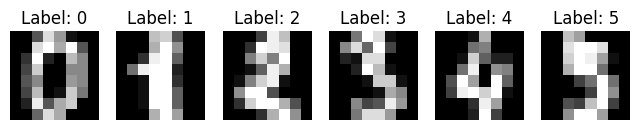

In [77]:
#Visualize Sample Images
plt.figure(figsize=(8,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f'Label: {y[i]}')
    plt.axis('off')
plt.show()

In [78]:
#Full SVD Decomposition
U, S, VT = np.linalg.svd(X_scaled, full_matrices=False)

print('U shape:', U.shape)
print('Σ length:', S.shape)
print('Vᵀ shape:', VT.shape)

U shape: (1797, 64)
Σ length: (64,)
Vᵀ shape: (64, 64)


In [79]:
#Dimensionality Reduction (k = 20)
k = 20
U_k = U[:, :k]
S_k = np.diag(S[:k])
VT_k = VT[:k, :]

X_reduced = U_k @ S_k
print('Reduced data shape:', X_reduced.shape)

Reduced data shape: (1797, 20)


Explained variance of first 10 components:
[0.12033916 0.09561054 0.08444415 0.06498408 0.04860155 0.0421412
 0.03942083 0.03389381 0.02998221 0.02932003]
Cumulative explained variance of first 10 components:
[0.12033916 0.21594971 0.30039385 0.36537793 0.41397948 0.45612068
 0.49554151 0.52943532 0.55941753 0.58873755]
Total variance captured by k components: 0.7931376270240807


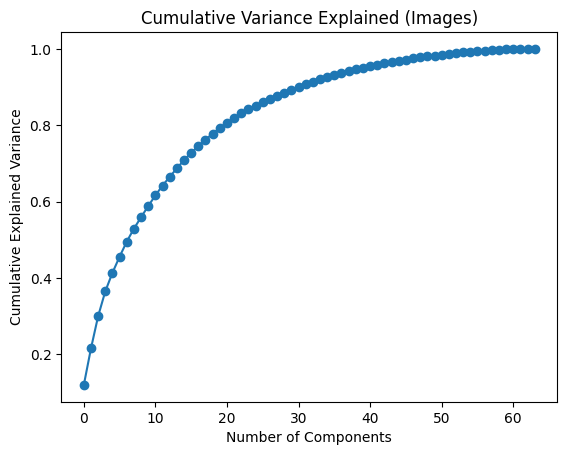

In [80]:
#Explained Variance by Singular Values
explained_variance = (S**2) / np.sum(S**2)

#Print variance values
print("Explained variance of first 10 components:")
print(explained_variance[:10])

print("Cumulative explained variance of first 10 components:")
print(np.cumsum(explained_variance[:10]))

print("Total variance captured by k components:", np.sum(explained_variance[:k]))

plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained (Images)')
plt.show()

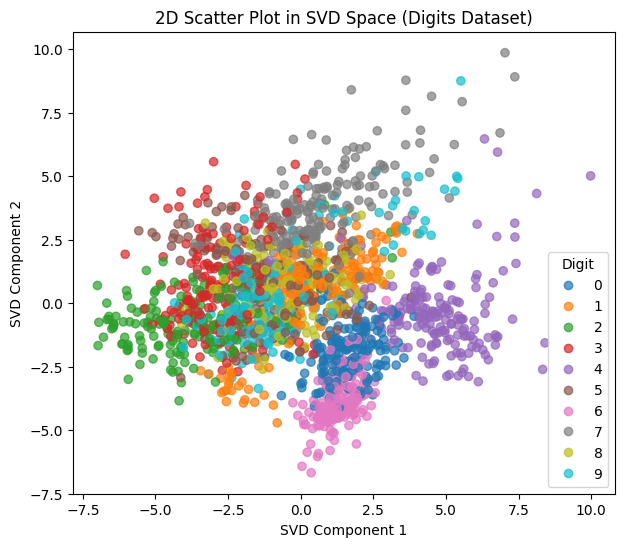

In [81]:
#2D Scatter plot using first two SVD components
k_scatter = 2
U_k_scatter = U[:, :k_scatter]
S_k_scatter = np.diag(S[:k_scatter])

X_2D = U_k_scatter @ S_k_scatter

plt.figure(figsize=(7,6))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("2D Scatter Plot in SVD Space (Digits Dataset)")
plt.legend(*scatter.legend_elements(), title="Digit")
plt.show()

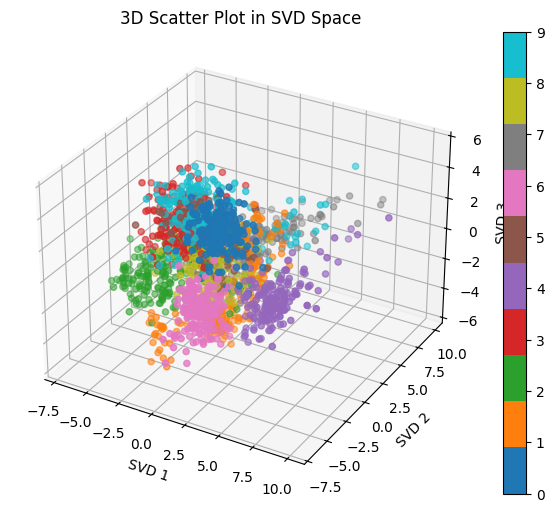

In [82]:
#3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D

k_scatter = 3
U_k_scatter = U[:, :k_scatter]
S_k_scatter = np.diag(S[:k_scatter])

X_3D = U_k_scatter @ S_k_scatter

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_3D[:,0], X_3D[:,1], X_3D[:,2], c=y, cmap='tab10')

ax.set_xlabel("SVD 1")
ax.set_ylabel("SVD 2")
ax.set_zlabel("SVD 3")
ax.set_title("3D Scatter Plot in SVD Space")
fig.colorbar(p)
plt.show()

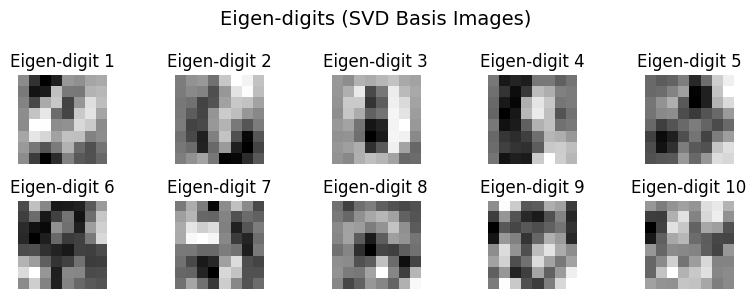

In [83]:
#Visualizing Eigen-digits (basis images)
num_eigendigits = 10  # show first 10 basis images

plt.figure(figsize=(8,3))
for i in range(num_eigendigits):
    plt.subplot(2, 5, i+1)
    eigendigit = VT[i].reshape(8, 8)
    plt.imshow(eigendigit, cmap='gray')
    plt.title(f"Eigen-digit {i+1}")
    plt.axis('off')

plt.suptitle("Eigen-digits (SVD Basis Images)", fontsize=14)
plt.tight_layout()
plt.show()

Original image shape: (8, 8)


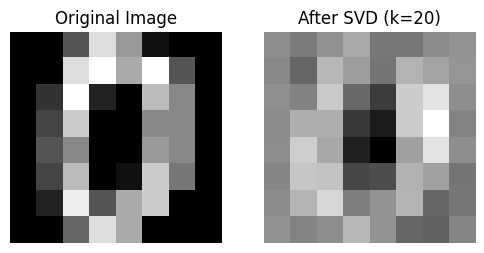

In [84]:
#Select an image index
image_index = 0

#Original image (raw pixel values)
original_image = digits.images[image_index]

print("Original image shape:", original_image.shape)

index = 0
#original_image = X_scaled[index].reshape(8,8)
reconstructed = (U_k[index] @ S_k @ VT_k).reshape(8,8)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title('After SVD (k=20)')
plt.axis('off')
plt.show()

**Multiclass Classification WITHOUT SVD**

In [85]:
#Multiclass Classification WITHOUT SVD
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf_no_svd = LogisticRegression(max_iter=5000, multi_class='ovr')
clf_no_svd.fit(X_train, y_train)
y_pred_no_svd = clf_no_svd.predict(X_test)
acc_no_svd = accuracy_score(y_test, y_pred_no_svd)
acc_no_svd

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9629629629629629

In [86]:
print("Classification Report WITHOUT SVD")
print(classification_report(y_test, y_pred_no_svd))

Classification Report WITHOUT SVD
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.92      0.94        50
           2       0.96      1.00      0.98        47
           3       0.98      0.93      0.95        54
           4       1.00      0.98      0.99        60
           5       0.94      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       0.85      0.95      0.90        43
           9       0.96      0.93      0.95        59

    accuracy                           0.96       540
   macro avg       0.96      0.96      0.96       540
weighted avg       0.96      0.96      0.96       540



**Multiclass Classification WITH SVD**

In [87]:
#Multiclass Classification WITH SVD
svd = TruncatedSVD(n_components=20, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

clf_svd = LogisticRegression(max_iter=5000, multi_class='ovr')
clf_svd.fit(X_train_svd, y_train)
y_pred_svd = clf_svd.predict(X_test_svd)
acc_svd = accuracy_score(y_test, y_pred_svd)
acc_svd

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9388888888888889

In [88]:
print("Classification Report WITH SVD")
print(classification_report(y_test, y_pred_svd))

Classification Report WITH SVD
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.91      0.78      0.84        50
           2       0.90      0.96      0.93        47
           3       0.96      0.87      0.91        54
           4       0.95      1.00      0.98        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.81      0.98      0.88        43
           9       0.91      0.90      0.91        59

    accuracy                           0.94       540
   macro avg       0.94      0.94      0.94       540
weighted avg       0.94      0.94      0.94       540



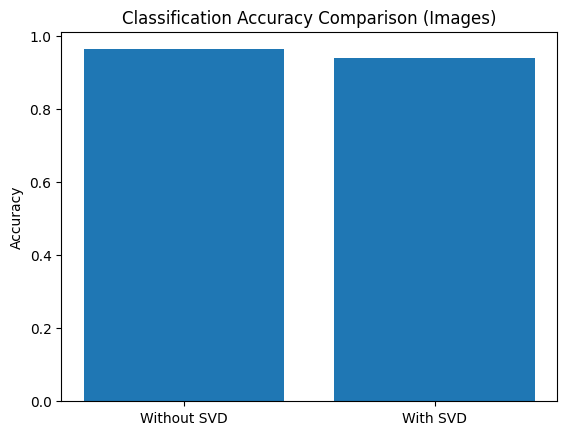

In [89]:
#Accuracy Comparison
plt.figure()
plt.bar(['Without SVD', 'With SVD'], [acc_no_svd, acc_svd])
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Comparison (Images)')
plt.show()

In [90]:
#Confusion Matrix (With SVD)
print(confusion_matrix(y_test, y_pred_svd))

[[52  0  1  0  0  0  0  0  0  0]
 [ 0 39  2  0  2  0  0  0  5  2]
 [ 0  2 45  0  0  0  0  0  0  0]
 [ 0  0  2 47  0  1  0  0  4  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  0 63  1  0  0  2]
 [ 0  0  0  0  1  0 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  2  0  2  0  1  0  0  1 53]]


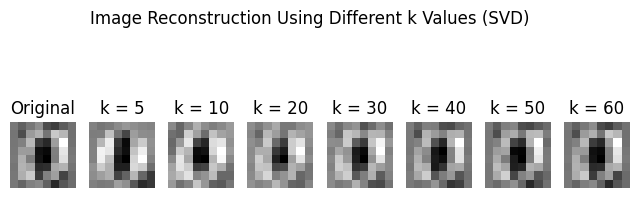

In [91]:
#Image reconstruction for different k values
image_index = 0  # choose any image
original = X_scaled[image_index].reshape(8,8)

k_values = [5, 10, 20, 30, 40, 50, 60]

plt.figure(figsize=(8,3))

#Original image
plt.subplot(1, len(k_values)+1, 1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

#Reconstructions
for i, k in enumerate(k_values):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]

    reconstructed = (U_k[image_index] @ S_k @ VT_k).reshape(8,8)

    plt.subplot(1, len(k_values)+1, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.suptitle("Image Reconstruction Using Different k Values (SVD)")
plt.show()